In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Height', ylabel='Height'>

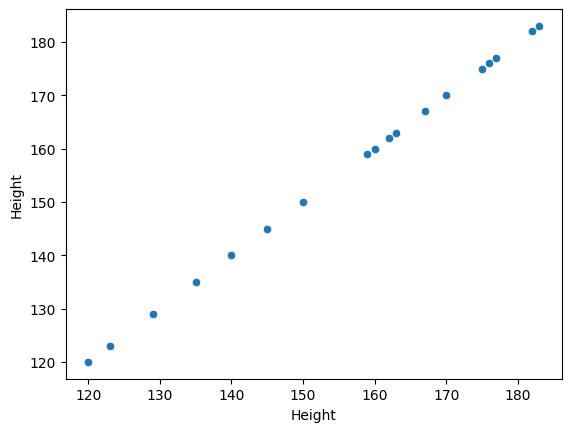

In [5]:
sns.scatterplot(x=df['Height'],y=df['Height'])

In [6]:
import numpy as np

(array([ 40.,  50.,  60.,  70.,  80.,  90., 100., 110.]),
 [Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60'),
  Text(70.0, 0, '70'),
  Text(80.0, 0, '80'),
  Text(90.0, 0, '90'),
  Text(100.0, 0, '100'),
  Text(110.0, 0, '110')])

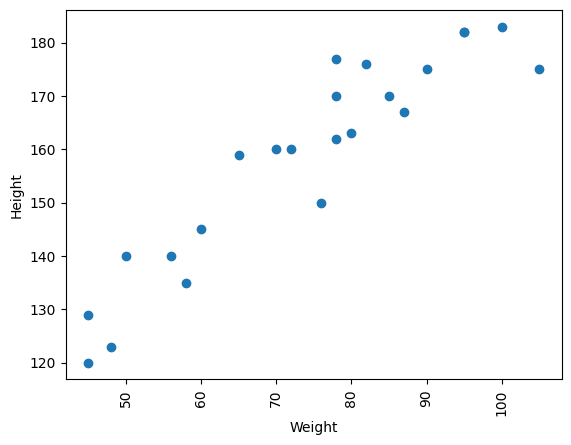

In [7]:
plt.scatter(x=df['Weight'],y=df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.xticks(rotation=90)

<Axes: >

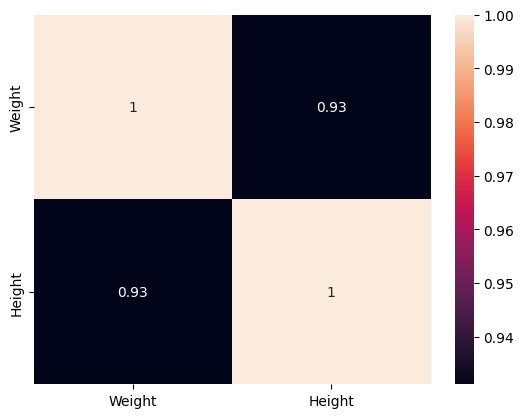

In [8]:
sns.heatmap(df.corr(),annot=True)

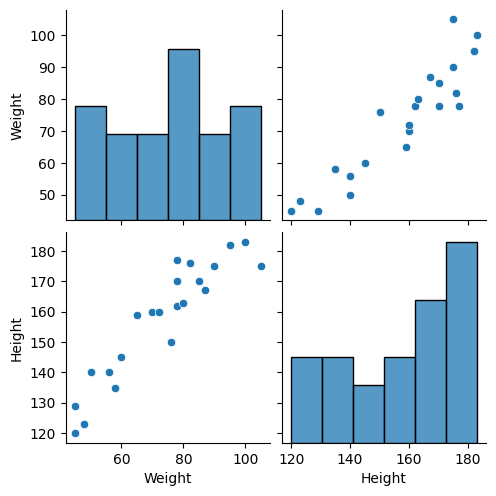

In [9]:
sns.pairplot(df)

In [10]:
# Dependent and independent variables
X = df[['Weight']] # Make sure Independent feature should be 2D array or a df
type(X)


pandas.DataFrame

In [11]:
X.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [12]:
y=df['Height']


In [13]:
# Train test split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

 Standardization 
For a simple height-weight model, standardization (converting values so the mean is 0 and standard deviation is 1) is used primarily to ensure numerical stability and fair feature comparison as weight is in kg and height is in cm, even if you only have one input like X. It helps the model converge faster during training and prevents issues with large feature values dominating the learning process.


In [14]:
# using Z score to get mean = 0 and standard deviation = 1

from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [16]:
# Print the calculated mean for each feature
print("Mean:", scaler.mean_)

# Print the calculated standard deviation for each feature
print("Standard Deviation:", scaler.scale_)


Mean: [72.47058824]
Standard Deviation: [16.50710238]


In [17]:
X_test = scaler.transform(X_test.values)

/home/yashwanth-aravind/ml-course/python-bootcamp/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


fit_transform on X_train: This does two jobs. First, fit calculates the mean and standard deviation of your training data. Second, transform uses those values to scale the training set.transform on X_test: This uses the exact same mean and scale calculated from the training data to shift the test data. This is crucial because you want to apply the same transformation to both sets to ensure consistency. If you were to fit_transform on the test set, it would calculate a different mean and standard deviation, leading to a mismatch in scaling between the training and test data, which can negatively impact model performance.

In [18]:
### Apply Simpple linear regression

from sklearn.linear_model import LinearRegression


In [19]:
regression = LinearRegression()

In [20]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
print("Coefficient or slope",regression.coef_)
print("Intercept: ",regression.intercept_)

Coefficient or slope [17.2982057]
Intercept:  156.47058823529412


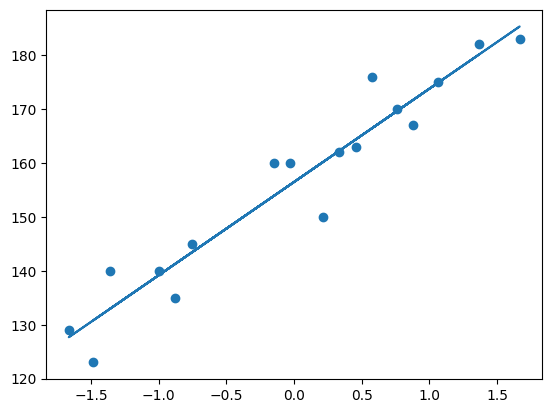

In [22]:
## Plot training data and plot best fit line for training samples

plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))


In [23]:
y_pred = regression.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [25]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(mse)
print("Mean Square Error: ",mse)
print("Mean Absolute Error: ",mae)
print("RMSE: ",rmse)

Mean Square Error:  114.84069295228699
Mean Absolute Error:  9.66512588679501
RMSE:  10.716374991212605


In [26]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
print("R2 value: ",r2)

R2 value:  0.7360826717981276


In [27]:
### OLS Linear Regression
import statsmodels.api as sm 
model = sm.OLS(y_train,X_train).fit()


In [28]:
prediction = model.predict(X_test)

In [29]:
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [30]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 23 Aug 2026   Prob (F-statistic):                       0.664
Time:                        10:27:02   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [31]:
### Predictino on new data

regression.predict(scaler.transform([[78]]))

/home/yashwanth-aravind/ml-course/python-bootcamp/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([162.26499721])

### From-scratch: gradient descent vs the normal equation

The cells above fit this model with `sklearn`'s `LinearRegression`, which solves the
normal equation internally. To show *why* that's equivalent to gradient descent
(and to check they actually agree), we implement both manually in plain NumPy on the
same scaled training data used above.

In [32]:
# Design matrix with an explicit bias column (x0 = 1), matching the theta notation in notes.md
X_gd = np.c_[np.ones(X_train.shape[0]), X_train]   # shape (m, 2): [1, weight_scaled]
y_gd = y_train.values

def gradient_descent(X, y, lr=0.1, n_iters=5000):
    m, n = X.shape
    theta = np.zeros(n)
    for _ in range(n_iters):
        preds = X @ theta
        grad = (1 / m) * X.T @ (preds - y)
        theta = theta - lr * grad
    return theta

theta_gd = gradient_descent(X_gd, y_gd)
print("Gradient descent theta [intercept, slope]:", theta_gd)

Gradient descent theta [intercept, slope]: [156.47058824  17.2982057 ]


In [33]:
# Closed-form normal equation: theta = (X^T X)^-1 X^T y
theta_normal = np.linalg.inv(X_gd.T @ X_gd) @ X_gd.T @ y_gd
print("Normal equation theta [intercept, slope]:", theta_normal)

print("sklearn LinearRegression intercept, slope:", regression.intercept_, regression.coef_)

print("GD and normal equation match within tolerance:",
      np.allclose(theta_gd, theta_normal, atol=1e-3))

Normal equation theta [intercept, slope]: [156.47058824  17.2982057 ]
sklearn LinearRegression intercept, slope: 156.47058823529412 [17.2982057]
GD and normal equation match within tolerance: True
